In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
customers = pd.read_csv("olist_customers_dataset.csv")
geolocation = pd.read_csv("olist_geolocation_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
product_category_name_translation = pd.read_csv("product_category_name_translation.csv")

In [6]:
from pandasql import sqldf

In [7]:
orders_main = orders \
    .merge(customers, on='customer_id', how='left') \
    .merge(payments, on='order_id', how='left')

In [8]:
orders_items = order_items \
    .merge(products, on='product_id', how='left') \
    .merge(product_category_name_translation, on='product_category_name', how='left') \
    .merge(sellers, on='seller_id', how='left')

In [9]:
df_full = orders_main \
    .merge(orders_items, on='order_id', how='left') \
    .merge(reviews[['order_id','review_score']], on='order_id', how='left')

df_full.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP,4.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP,4.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP,4.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,1.0,400.0,19.0,13.0,19.0,perfumery,31570.0,belo horizonte,SP,4.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1.0,420.0,24.0,19.0,21.0,auto,14840.0,guariba,SP,5.0


In [10]:
pysql = lambda q: sqldf(q, globals())

In [11]:
q1 = """
    SELECT customer_city, COUNT(order_id) as order_count
    FROM df_full
    GROUP BY customer_city
    ORDER BY order_count DESC
    LIMIT 10
"""

result = pysql(q1)
print(result)

           customer_city  order_count
0              sao paulo        18875
1         rio de janeiro         8311
2         belo horizonte         3299
3               brasilia         2500
4               curitiba         1827
5               campinas         1757
6           porto alegre         1675
7               salvador         1544
8              guarulhos         1415
9  sao bernardo do campo         1131


In [12]:
q2 = """
    SELECT product_category_name_english as category, COUNT(order_id) as count
    FROM df_full
    GROUP BY category
    ORDER BY count DESC
    LIMIT 10
"""

result = pysql(q2)
print(result)

                category  count
0         bed_bath_table  11988
1          health_beauty  10032
2         sports_leisure   9004
3        furniture_decor   8832
4  computers_accessories   8150
5             housewares   7380
6          watches_gifts   6213
7              telephony   4726
8           garden_tools   4590
9                   auto   4400


In [13]:
q3 = """
    SELECT *
    FROM (
        SELECT 
            product_category_name_english as category,
            product_id,
            COUNT(order_id) as order_count,
            RANK() OVER (
                PARTITION BY product_category_name_english 
                ORDER BY COUNT(order_id) DESC
            ) as rank
        FROM df_full
        GROUP BY product_category_name_english
    )
    WHERE rank = 1
    ORDER BY order_count DESC
    LIMIT 10
"""

top_products = pysql(q3)
print(top_products)

                category                        product_id  order_count  rank
0         bed_bath_table  10adb53d8faa890ca7c2f0cbcb68d777        11988     1
1          health_beauty  5ac9d9e379c606e36a8094a6046f75dc        10032     1
2         sports_leisure  cd935d283d47f1050c505e1c39c48b67         9004     1
3        furniture_decor  ac1789e492dcd698c5c10b97a671243a         8832     1
4  computers_accessories  f7e0fa615b386bc9a8b9eb52bc1fff76         8150     1
5             housewares  87285b34884572647811a353c7ac498a         7380     1
6          watches_gifts  ba74c6b75d2ad7503175809688d5a03c         6213     1
7              telephony  a47295965bd091207681b541b26e40a5         4726     1
8           garden_tools  08574b074924071f4e201e151b152b4e         4590     1
9                   auto  aa4383b373c6aca5d8797843e5594415         4400     1


In [14]:
q4 = """
    SELECT 
        STRFTIME('%Y-%m', order_purchase_timestamp) as month,
        COUNT(order_id) as order_count,
        ROUND(SUM(price - freight_value), 2) as total_profit
    FROM df_full
    GROUP BY month
    ORDER BY month ASC
"""

monthly = pysql(q4)
print(monthly)

      month  order_count  total_profit
0   2016-09            7        179.97
1   2016-10          401      43406.99
2   2016-12            1          2.18
3   2017-01         1035     111760.53
4   2017-02         2123     220379.41
5   2017-03         3243     336456.24
6   2017-04         2878     335482.91
7   2017-05         4485     463691.46
8   2017-06         3853     382682.88
9   2017-07         4949     442472.35
10  2017-08         5278     505885.01
11  2017-09         5186     562769.06
12  2017-10         5683     586003.31
13  2017-11         9191     878069.90
14  2017-12         6645     648720.12
15  2018-01         8655     828660.14
16  2018-02         8057     740012.93
17  2018-03         8615     850099.04
18  2018-04         8277     862333.03
19  2018-05         8258     872193.86
20  2018-06         7403     744352.62
21  2018-07         7376     756863.22
22  2018-08         7524     731067.30
23  2018-09           16        123.54
24  2018-10            4 

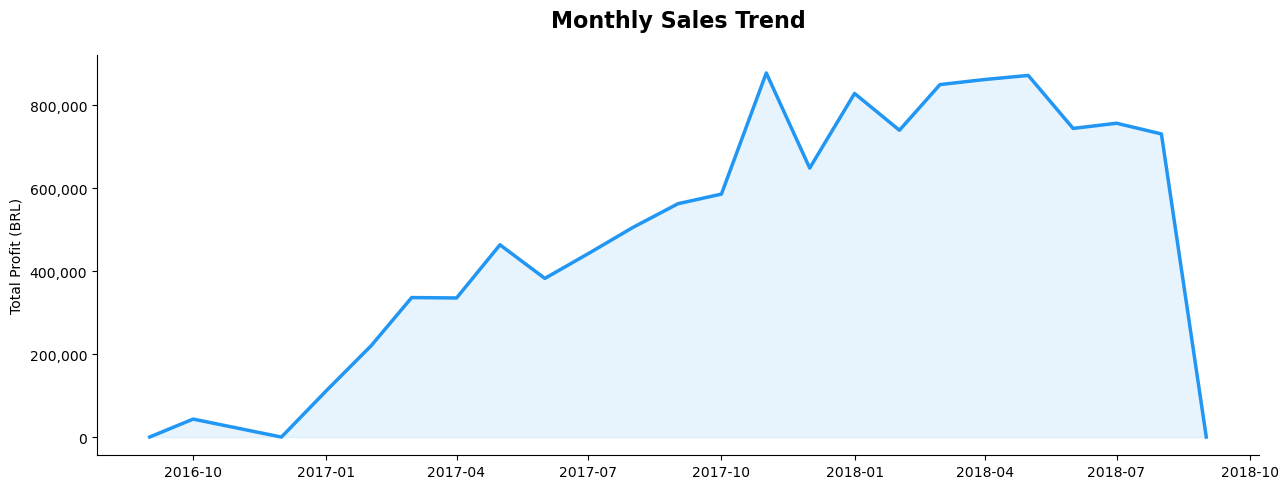

In [17]:
monthly["month"] = pd.to_datetime(monthly["month"])

fig, ax = plt.subplots(figsize=(13, 5))
sns.lineplot(data=monthly, x="month", y="total_profit", color="#2196F3", linewidth=2.5, ax=ax)
ax.fill_between(monthly["month"], monthly["total_profit"], alpha=0.1, color="#2196F3")
ax.set_title("Monthly Sales Trend", fontsize=16, fontweight="bold", pad=20)
ax.set_xlabel("")
ax.set_ylabel("Total Profit (BRL)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
sns.despine()
plt.tight_layout()
plt.show()